# FastRelax Post-processing Visualization

This notebook visualizes the results from FastRelax post-processing.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

plot_dir = Path('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval/fastrelax_plots')
plot_dir.mkdir(parents=True, exist_ok=True)

## Load Data

In [3]:
# Load the summary CSV file
csv_file = '/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval/fastrelax_post_summary.csv'
df = pd.read_csv(csv_file)

print(f"Loaded {len(df)} records")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 5565 records
Columns: ['complex', 'seed', 'het_id', 'total_score', 'Δtotal_score', 'fa_rep', 'Δfa_rep', 'lig_rmsd_before_after', 'rec_rmsd_before_after', 'ifp_similarity', 'before_pdb', 'after_pdb', 'lig_rmsd_among_seeds_mean', 'lig_rmsd_among_seeds_std', 'rec_rmsd_among_seeds_mean', 'rec_rmsd_among_seeds_std']


,complex,seed,het_id,total_score,Δtotal_score,fa_rep,Δfa_rep,lig_rmsd_before_after,rec_rmsd_before_after,ifp_similarity,before_pdb,after_pdb,lig_rmsd_among_seeds_mean,lig_rmsd_among_seeds_std,rec_rmsd_among_seeds_mean,rec_rmsd_among_seeds_std
0,complex_0081_off03,seed0,4RJ,17.861022,-789.986702,73.968806,-538.084918,0.419322,0.265178,NaN,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,1.265750,0.001367,0.040743,0.001625
1,complex_0081_off03,seed1,4RJ,17.379750,-734.951832,73.110905,-484.634155,0.351498,0.264582,NaN,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,0.347452,0.529014,0.031546,0.006986
2,complex_0081_off03,seed2,4RJ,18.463856,-736.932520,73.333615,-486.641189,0.371247,0.263418,NaN,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,0.353783,0.526672,0.031027,0.007600
3,complex_0081_off03,seed3,4RJ,19.586402,-720.827217,73.330330,-472.281224,0.351250,0.263266,NaN,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,0.350891,0.529247,0.028323,0.007006
4,complex_0081_off03,seed4,4RJ,19.871316,-730.156041,73.572041,-482.066290,0.370262,0.263821,NaN,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,0.351345,0.527975,0.031131,0.007958


In [4]:
# Basic statistics
df.describe()

,total_score,Δtotal_score,fa_rep,Δfa_rep,lig_rmsd_before_after,rec_rmsd_before_after,ifp_similarity,lig_rmsd_among_seeds_mean,lig_rmsd_among_seeds_std,rec_rmsd_among_seeds_mean,rec_rmsd_among_seeds_std
count,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,0.0,5565.000000,5565.000000,5565.000000,5565.000000
mean,6474.762576,-1805.154786,2531.179480,-1580.300298,1.416495,0.274185,NaN,3.671278,2.007024,0.098760,0.014904
std,3693.723879,1696.810790,2570.788546,1575.145155,1.575371,0.031504,NaN,3.984534,2.238961,0.052248,0.015184
min,17.379750,-11394.127276,68.719013,-11391.375601,0.129218,0.187625,NaN,0.036540,0.001090,0.017800,0.000214
25%,3767.157643,-2570.481812,489.945598,-2223.179824,0.656384,0.255057,NaN,0.719589,0.225649,0.059652,0.004660
50%,5805.012099,-1570.854890,1670.059704,-1291.742704,0.911743,0.274433,NaN,2.269540,1.092046,0.084634,0.009153
75%,8269.929499,-924.230068,3853.753481,-791.928062,1.379695,0.291706,NaN,5.336703,3.169238,0.129776,0.020294
max,28833.313052,9523.630334,18862.133491,6497.725093,17.481124,0.442352,NaN,37.488200,14.820721,0.359664,0.123201


## 1. Rosetta Energy Distribution

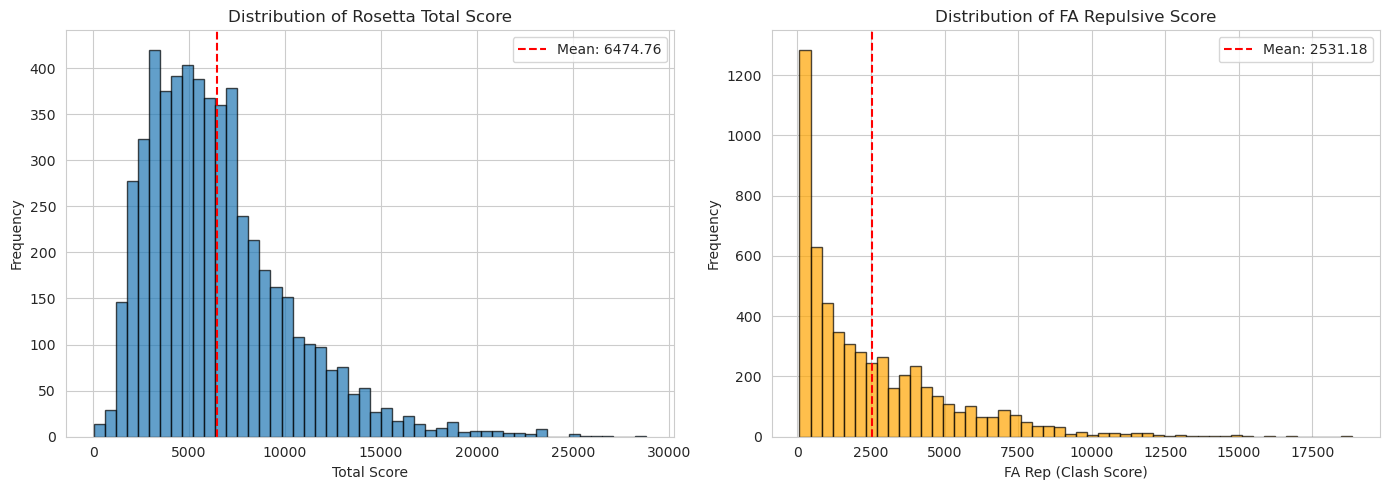

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Score
axes[0].hist(df['total_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['total_score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["total_score"].mean():.2f}')
axes[0].set_xlabel('Total Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Rosetta Total Score')
axes[0].legend()

# FA Rep
axes[1].hist(df['fa_rep'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(df['fa_rep'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["fa_rep"].mean():.2f}')
axes[1].set_xlabel('FA Rep (Clash Score)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of FA Repulsive Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(plot_dir / 'rosetta_energy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

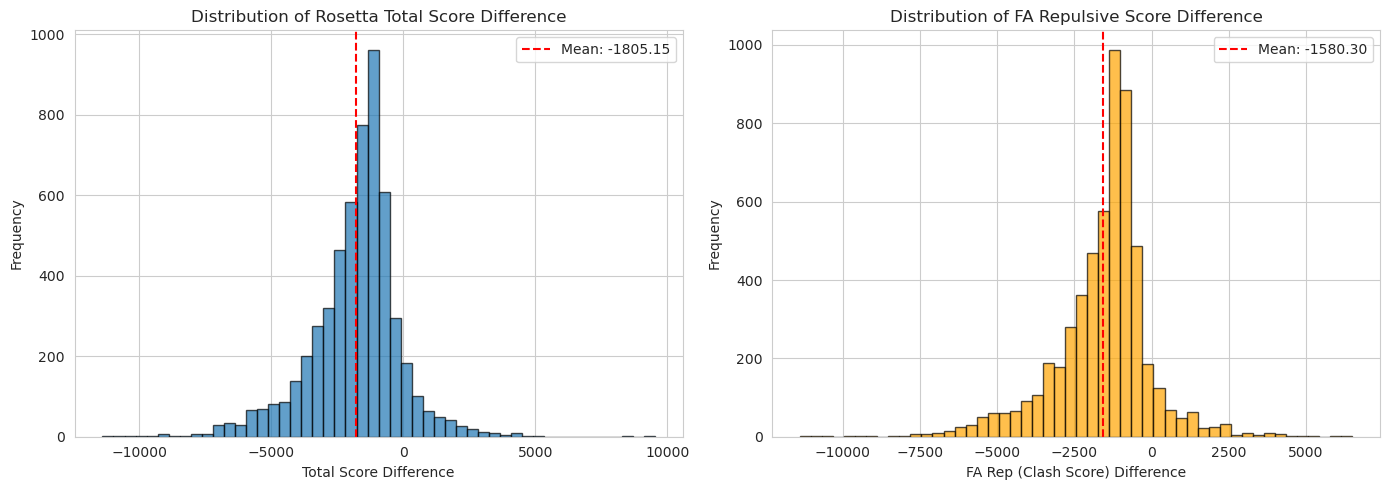

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Score
axes[0].hist(df['Δtotal_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Δtotal_score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["Δtotal_score"].mean():.2f}')
axes[0].set_xlabel('Total Score Difference')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Rosetta Total Score Difference')
axes[0].legend()

# FA Rep
axes[1].hist(df['Δfa_rep'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(df['Δfa_rep'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Δfa_rep"].mean():.2f}')
axes[1].set_xlabel('FA Rep (Clash Score) Difference')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of FA Repulsive Score Difference')
axes[1].legend()

plt.tight_layout()
plt.savefig(plot_dir / 'rosetta_energy_difference_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. RMSD Before/After Relaxation

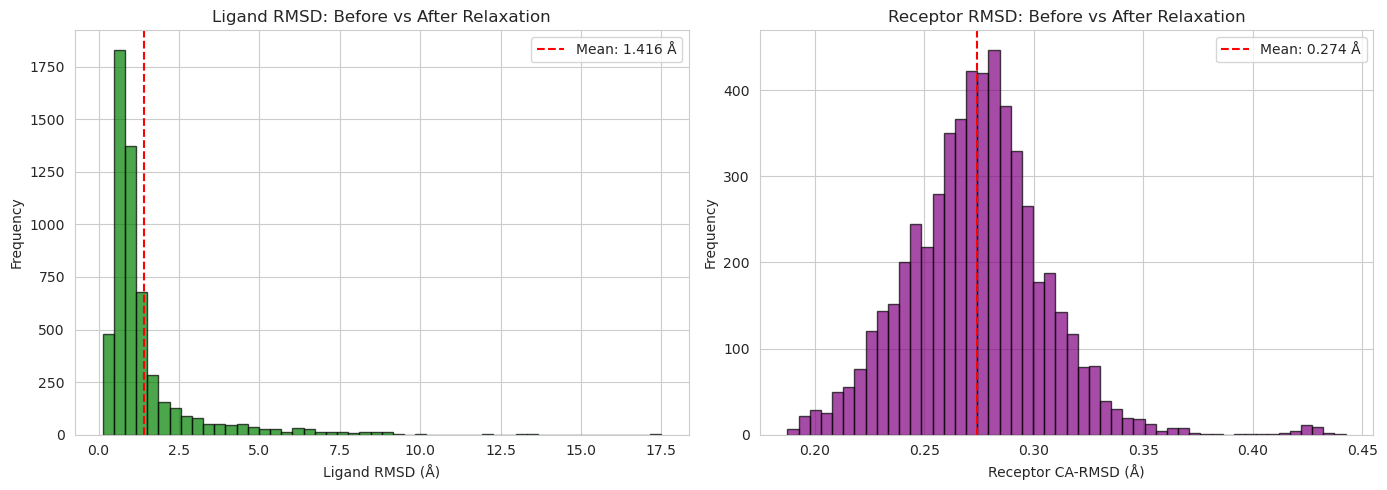

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ligand RMSD
axes[0].hist(df['lig_rmsd_before_after'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].axvline(df['lig_rmsd_before_after'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["lig_rmsd_before_after"].mean():.3f} Å')
axes[0].set_xlabel('Ligand RMSD (Å)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Ligand RMSD: Before vs After Relaxation')
axes[0].legend()

# Receptor RMSD
axes[1].hist(df['rec_rmsd_before_after'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].axvline(df['rec_rmsd_before_after'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["rec_rmsd_before_after"].mean():.3f} Å')
axes[1].set_xlabel('Receptor CA-RMSD (Å)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Receptor RMSD: Before vs After Relaxation')
axes[1].legend()

plt.tight_layout()
plt.savefig(plot_dir / 'rmsd_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. RMSD Among Seeds (Reproducibility)

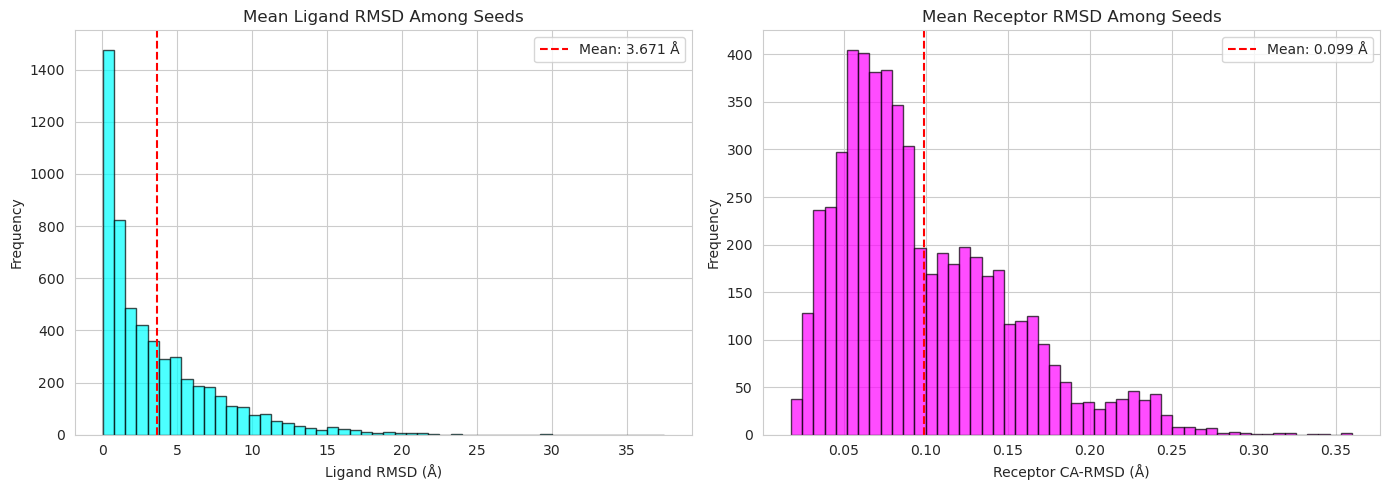

In [10]:
if 'lig_rmsd_among_seeds_mean' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Ligand RMSD among seeds
    axes[0].hist(df['lig_rmsd_among_seeds_mean'].dropna(), bins=50, 
                 edgecolor='black', alpha=0.7, color='cyan')
    axes[0].axvline(df['lig_rmsd_among_seeds_mean'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df["lig_rmsd_among_seeds_mean"].mean():.3f} Å')
    axes[0].set_xlabel('Ligand RMSD (Å)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Mean Ligand RMSD Among Seeds')
    axes[0].legend()
    
    # Receptor RMSD among seeds
    axes[1].hist(df['rec_rmsd_among_seeds_mean'].dropna(), bins=50,
                 edgecolor='black', alpha=0.7, color='magenta')
    axes[1].axvline(df['rec_rmsd_among_seeds_mean'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df["rec_rmsd_among_seeds_mean"].mean():.3f} Å')
    axes[1].set_xlabel('Receptor CA-RMSD (Å)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Mean Receptor RMSD Among Seeds')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(plot_dir / 'rmsd_among_seeds.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("RMSD among seeds data not available")

## 4. IFP Similarity

In [11]:
if 'ifp_similarity' in df.columns and df['ifp_similarity'].notna().sum() > 0:
    plt.figure(figsize=(10, 6))
    plt.hist(df['ifp_similarity'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='teal')
    plt.axvline(df['ifp_similarity'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["ifp_similarity"].mean():.3f}')
    plt.xlabel('IFP Similarity')
    plt.ylabel('Frequency')
    plt.title('Interaction Fingerprint Similarity (Before vs After)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / 'ifp_similarity.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("IFP similarity data not available")

IFP similarity data not available


## 5. Score vs RMSD Scatter Plots

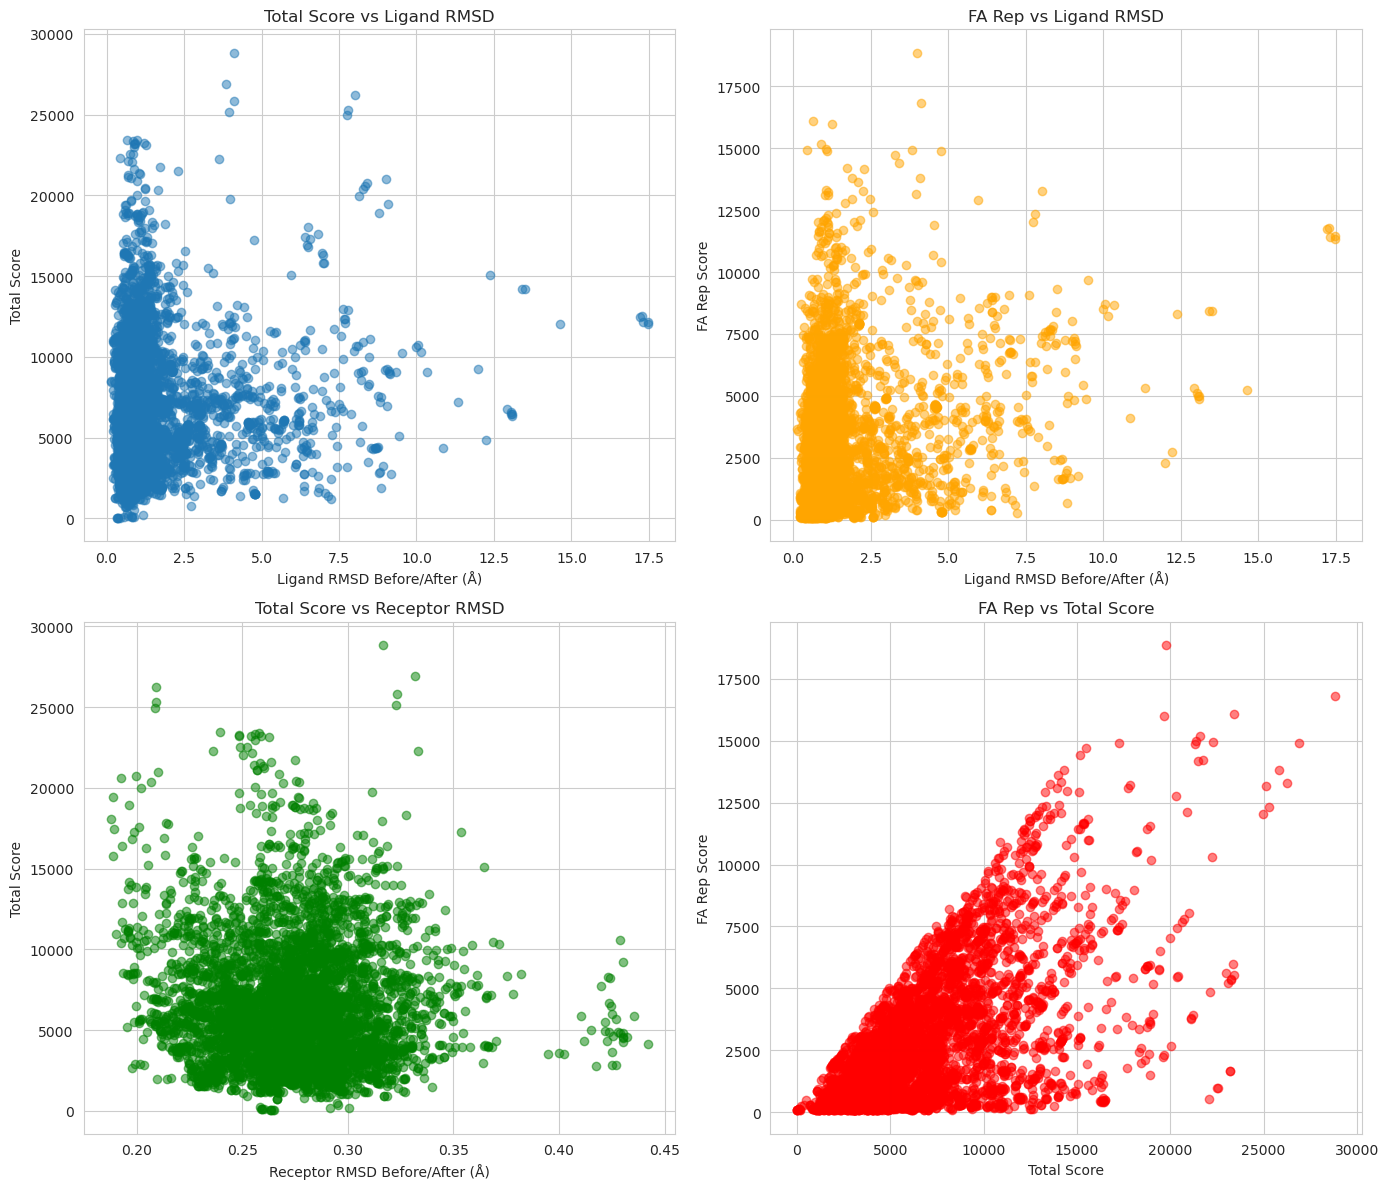

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Total Score vs Ligand RMSD
axes[0, 0].scatter(df['lig_rmsd_before_after'], df['total_score'], alpha=0.5)
axes[0, 0].set_xlabel('Ligand RMSD Before/After (Å)')
axes[0, 0].set_ylabel('Total Score')
axes[0, 0].set_title('Total Score vs Ligand RMSD')

# FA Rep vs Ligand RMSD
axes[0, 1].scatter(df['lig_rmsd_before_after'], df['fa_rep'], alpha=0.5, color='orange')
axes[0, 1].set_xlabel('Ligand RMSD Before/After (Å)')
axes[0, 1].set_ylabel('FA Rep Score')
axes[0, 1].set_title('FA Rep vs Ligand RMSD')

# Total Score vs Receptor RMSD
axes[1, 0].scatter(df['rec_rmsd_before_after'], df['total_score'], alpha=0.5, color='green')
axes[1, 0].set_xlabel('Receptor RMSD Before/After (Å)')
axes[1, 0].set_ylabel('Total Score')
axes[1, 0].set_title('Total Score vs Receptor RMSD')

# FA Rep vs Total Score
axes[1, 1].scatter(df['total_score'], df['fa_rep'], alpha=0.5, color='red')
axes[1, 1].set_xlabel('Total Score')
axes[1, 1].set_ylabel('FA Rep Score')
axes[1, 1].set_title('FA Rep vs Total Score')

plt.tight_layout()
plt.savefig(plot_dir / 'score_rmsd_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Per-Complex Analysis

In [13]:
# Group by complex and calculate statistics
complex_stats = df.groupby('complex').agg({
    'total_score': ['mean', 'std', 'min'],
    'fa_rep': ['mean', 'std', 'min'],
    'lig_rmsd_before_after': ['mean', 'std'],
    'rec_rmsd_before_after': ['mean', 'std']
}).round(3)

print("\nPer-complex statistics:")
print(complex_stats.head(10))

# Save per-complex stats
complex_stats.to_csv(plot_dir / 'fastrelax_per_complex_stats.csv')
print("\nSaved per-complex statistics to fastrelax_per_complex_stats.csv")


Per-complex statistics:
                   total_score                       fa_rep           \
                          mean      std       min      mean      std   
complex                                                                
complex_0081_off03      18.632    1.077    17.380    73.463    0.326   
complex_0082_off03    3773.532  701.678  2864.479  2772.210  318.535   
complex_0083_off03    3416.364   23.333  3386.288   319.250    8.175   
complex_0084_off03    3433.393   38.328  3393.978   321.422    4.878   
complex_0085_off03    3366.178   10.406  3348.968   407.295    6.623   
complex_0086_off03    3360.194    9.148  3352.874   401.194   11.715   
complex_0087_off03    3323.691   18.015  3301.506   238.401    6.960   
complex_0088_off03    3309.179   29.242  3276.223   237.412    8.273   
complex_0089_off03    4124.949  384.913  3767.325  1686.132  368.776   
complex_0130_off01    6075.826   23.690  6046.562   595.069   14.024   

                             lig_rmsd_

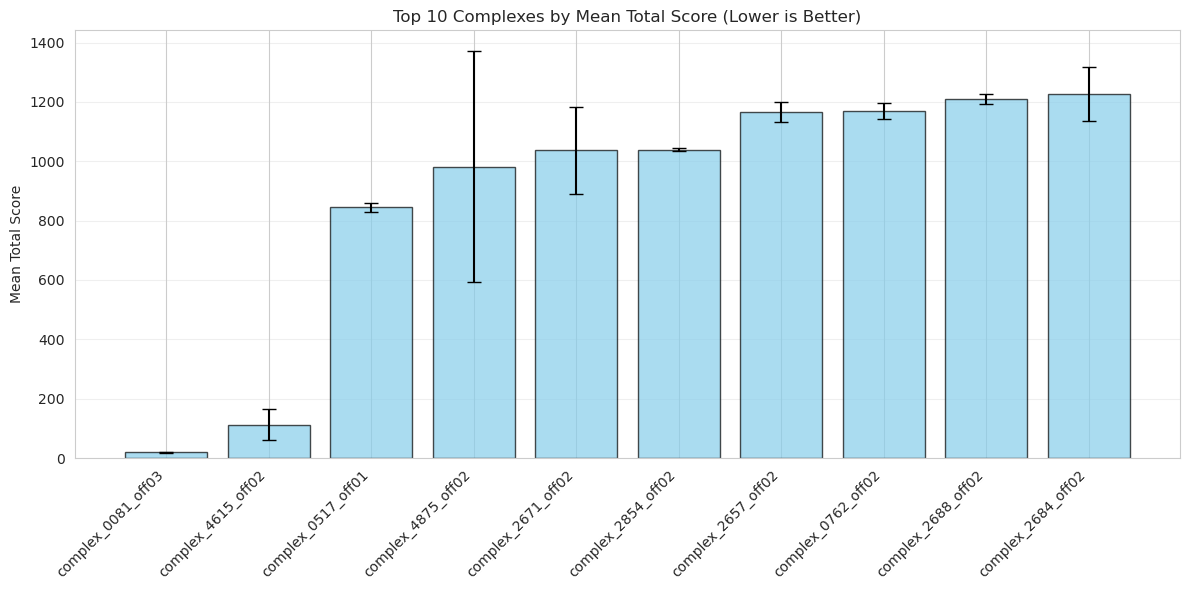

In [14]:
# Plot top 10 complexes by mean total score
top_complexes = complex_stats.sort_values(('total_score', 'mean')).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top_complexes))
y = top_complexes[('total_score', 'mean')].values
yerr = top_complexes[('total_score', 'std')].values

ax.bar(x, y, yerr=yerr, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(top_complexes.index, rotation=45, ha='right')
ax.set_ylabel('Mean Total Score')
ax.set_title('Top 10 Complexes by Mean Total Score (Lower is Better)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(plot_dir / 'top_complexes.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Seed-wise Comparison

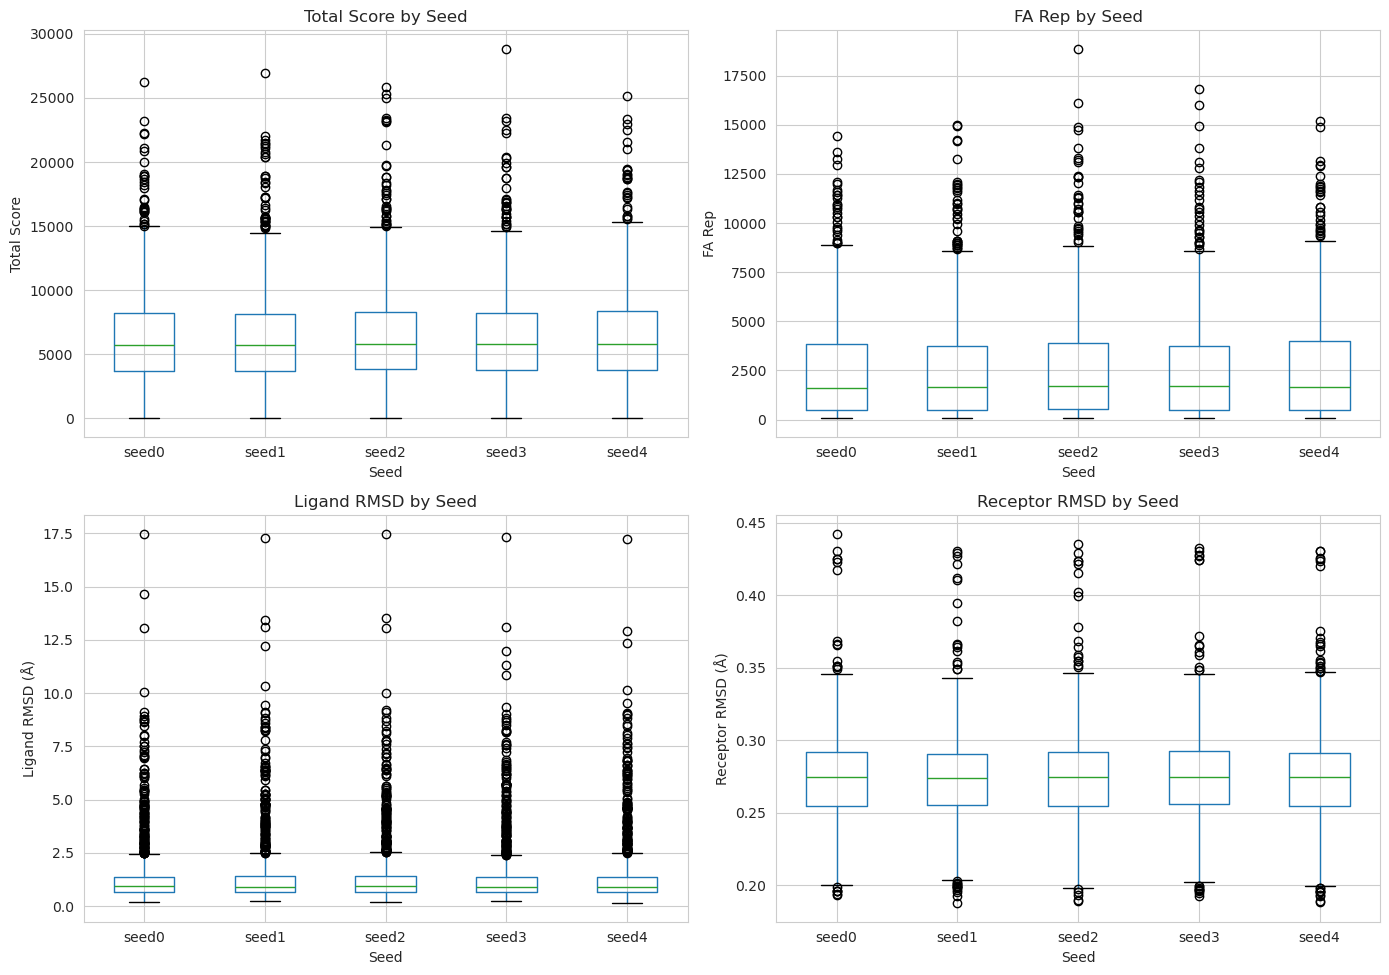

In [15]:
# Box plot for each seed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Score by seed
df.boxplot(column='total_score', by='seed', ax=axes[0, 0])
axes[0, 0].set_title('Total Score by Seed')
axes[0, 0].set_xlabel('Seed')
axes[0, 0].set_ylabel('Total Score')

# FA Rep by seed
df.boxplot(column='fa_rep', by='seed', ax=axes[0, 1])
axes[0, 1].set_title('FA Rep by Seed')
axes[0, 1].set_xlabel('Seed')
axes[0, 1].set_ylabel('FA Rep')

# Ligand RMSD by seed
df.boxplot(column='lig_rmsd_before_after', by='seed', ax=axes[1, 0])
axes[1, 0].set_title('Ligand RMSD by Seed')
axes[1, 0].set_xlabel('Seed')
axes[1, 0].set_ylabel('Ligand RMSD (Å)')

# Receptor RMSD by seed
df.boxplot(column='rec_rmsd_before_after', by='seed', ax=axes[1, 1])
axes[1, 1].set_title('Receptor RMSD by Seed')
axes[1, 1].set_xlabel('Seed')
axes[1, 1].set_ylabel('Receptor RMSD (Å)')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(plot_dir / 'seed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary Report

In [16]:
print("="*60)
print("FastRelax Post-processing Summary Report")
print("="*60)
print(f"\nTotal number of relaxed structures: {len(df)}")
print(f"Number of unique complexes: {df['complex'].nunique()}")
print(f"Number of unique ligands: {df['het_id'].nunique()}")

print("\n--- Rosetta Energy Statistics ---")
print(f"Mean Total Score: {df['total_score'].mean():.2f} ± {df['total_score'].std():.2f}")
print(f"Median Total Score: {df['total_score'].median():.2f}")
print(f"Best Total Score: {df['total_score'].min():.2f}")
print(f"\nMean FA Rep: {df['fa_rep'].mean():.2f} ± {df['fa_rep'].std():.2f}")
print(f"Median FA Rep: {df['fa_rep'].median():.2f}")

print("\n--- RMSD Statistics (Before/After) ---")
print(f"Mean Ligand RMSD: {df['lig_rmsd_before_after'].mean():.3f} ± {df['lig_rmsd_before_after'].std():.3f} Å")
print(f"Median Ligand RMSD: {df['lig_rmsd_before_after'].median():.3f} Å")
print(f"\nMean Receptor RMSD: {df['rec_rmsd_before_after'].mean():.3f} ± {df['rec_rmsd_before_after'].std():.3f} Å")
print(f"Median Receptor RMSD: {df['rec_rmsd_before_after'].median():.3f} Å")

if 'lig_rmsd_among_seeds_mean' in df.columns:
    print("\n--- RMSD Statistics (Among Seeds) ---")
    print(f"Mean Ligand RMSD: {df['lig_rmsd_among_seeds_mean'].mean():.3f} ± {df['lig_rmsd_among_seeds_mean'].std():.3f} Å")
    print(f"Mean Receptor RMSD: {df['rec_rmsd_among_seeds_mean'].mean():.3f} ± {df['rec_rmsd_among_seeds_mean'].std():.3f} Å")

if 'ifp_similarity' in df.columns and df['ifp_similarity'].notna().sum() > 0:
    print("\n--- IFP Similarity Statistics ---")
    print(f"Mean IFP Similarity: {df['ifp_similarity'].mean():.3f} ± {df['ifp_similarity'].std():.3f}")
    print(f"Median IFP Similarity: {df['ifp_similarity'].median():.3f}")

print("\n" + "="*60)

FastRelax Post-processing Summary Report

Total number of relaxed structures: 5565
Number of unique complexes: 1113
Number of unique ligands: 737

--- Rosetta Energy Statistics ---
Mean Total Score: 6474.76 ± 3693.72
Median Total Score: 5805.01
Best Total Score: 17.38

Mean FA Rep: 2531.18 ± 2570.79
Median FA Rep: 1670.06

--- RMSD Statistics (Before/After) ---
Mean Ligand RMSD: 1.416 ± 1.575 Å
Median Ligand RMSD: 0.912 Å

Mean Receptor RMSD: 0.274 ± 0.032 Å
Median Receptor RMSD: 0.274 Å

--- RMSD Statistics (Among Seeds) ---
Mean Ligand RMSD: 3.671 ± 3.985 Å
Mean Receptor RMSD: 0.099 ± 0.052 Å

